In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import scipy.stats as stats

In [ ]:
df1 = pd.read_csv("/content/492805_39.97_-104.66_2006.csv")

In [ ]:
df2 = pd.read_csv("/content/Actual_39.95_-104.65_2006_UPV_100MW_5_Min.csv")

The Dataset used is a combination of two datasets, one is the power generation
data (MW) over a year 2006 from 1st january 2006 to 31st December 2006. The power data is collected at a time interval of 5 minutes for entire day.
Whereas the other data is weather data obtained from NREL website for same location as well as same year. But the weather data is compiled at a time interval of 30 minutes. Therefore we need to perform some methods to combine both the datasets and get a combined dataset.

In [ ]:
df1.head()

,Year,Month,Day,Hour,Minute,Temperature,Clearsky DHI,Clearsky DNI,Clearsky GHI,Cloud Type,...,GHI,Relative Humidity,Solar Zenith Angle,Surface Albedo,Pressure,Precipitable Water,Wind Direction,Wind Speed,Global Horizontal UV Irradiance (280-400nm),Global Horizontal UV Irradiance (295-385nm)
0,2006,1,1,0,0,7.1,0,0,0,0,...,0,53.04,93.61,0.2,820,1.3,358,1.4,0.0,0.0
1,2006,1,1,0,30,6.7,0,0,0,0,...,0,54.58,98.82,0.2,821,1.3,353,1.4,0.0,0.0
2,2006,1,1,1,0,6.4,0,0,0,4,...,0,55.85,104.20,0.2,821,1.3,349,1.4,0.0,0.0
3,2006,1,1,1,30,6.2,0,0,0,7,...,0,56.56,109.71,0.2,820,1.3,341,1.3,0.0,0.0
4,2006,1,1,2,0,6.0,0,0,0,4,...,0,57.83,115.33,0.2,820,1.3,333,1.3,0.0,0.0


In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17520 entries, 0 to 17519
Data columns (total 23 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   Year                                         17520 non-null  int64  
 1   Month                                        17520 non-null  int64  
 2   Day                                          17520 non-null  int64  
 3   Hour                                         17520 non-null  int64  
 4   Minute                                       17520 non-null  int64  
 5   Temperature                                  17520 non-null  float64
 6   Clearsky DHI                                 17520 non-null  int64  
 7   Clearsky DNI                                 17520 non-null  int64  
 8   Clearsky GHI                                 17520 non-null  int64  
 9   Cloud Type                                   17520 non-null  int64  
 10

Converting Seperate columns for date, time, hour, minute into one Date Column

In [ ]:
df1['Date']=pd.to_datetime(df1[['Year','Month','Day','Hour','Minute']])

In [ ]:
temp_cols=df1.columns.tolist()
new_cols=temp_cols[-1:] + temp_cols[:-1]
df1=df1[new_cols]

Power Generation Data

In [ ]:
df2.head()

,LocalTime,Power(MW)
0,01/01/06 00:00,0.0
1,01/01/06 00:05,0.0
2,01/01/06 00:10,0.0
3,01/01/06 00:15,0.0
4,01/01/06 00:20,0.0


In [ ]:
df2['LocalTime'] = pd.to_datetime(df2['LocalTime'])

<ipython-input-9-65f949048ccd>:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df2['LocalTime'] = pd.to_datetime(df2['LocalTime'])


Converting 5 minute interval data into 30 minute interval

In [ ]:
df3 = df2.groupby(pd.Grouper(key='LocalTime', freq='30T')).mean().reset_index()

<ipython-input-10-32951b292af2>:1: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df3 = df2.groupby(pd.Grouper(key='LocalTime', freq='30T')).mean().reset_index()


In [ ]:
df3.head()

,LocalTime,Power(MW)
0,2006-01-01 00:00:00,0.0
1,2006-01-01 00:30:00,0.0
2,2006-01-01 01:00:00,0.0
3,2006-01-01 01:30:00,0.0
4,2006-01-01 02:00:00,0.0


Inserting Power Output column to weather data

In [ ]:
df1.insert(6, "Power Output(MW)", df3['Power(MW)'], True)

Power Output Histogram

<Axes: xlabel='Power Output(MW)', ylabel='Count'>

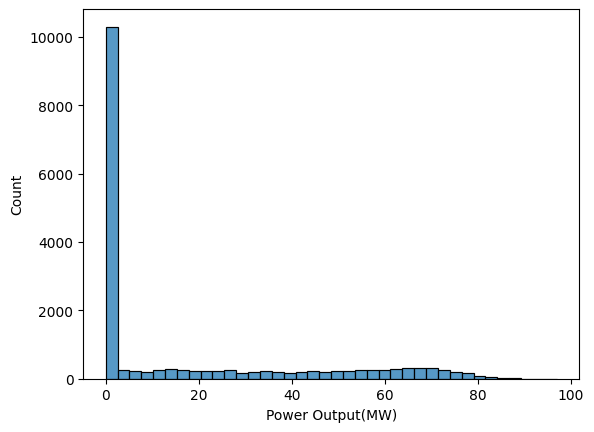

In [ ]:
sns.histplot(data = df1,x = "Power Output(MW)")

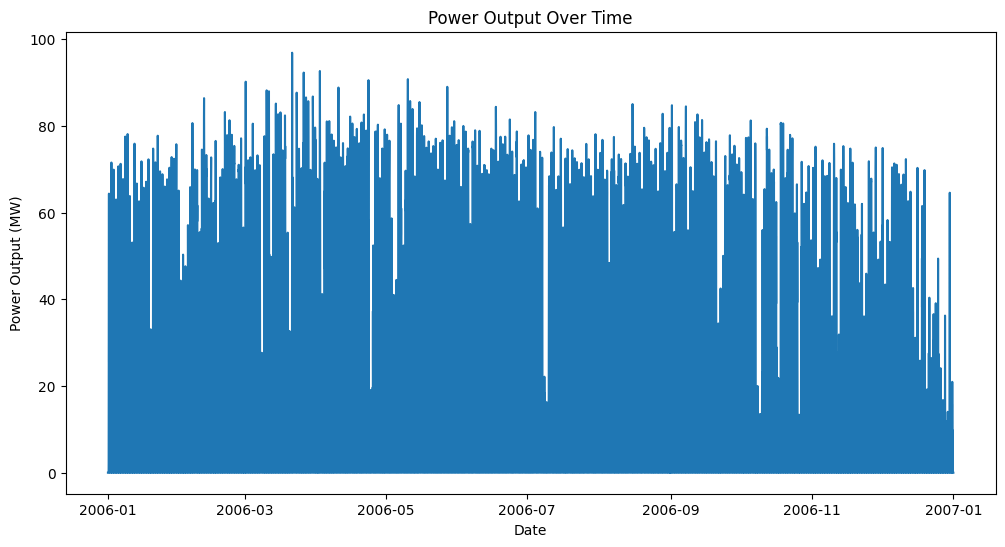

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(df1['Date'], df1['Power Output(MW)'])
plt.xlabel('Date')
plt.ylabel('Power Output (MW)')
plt.title('Power Output Over Time')
plt.show()

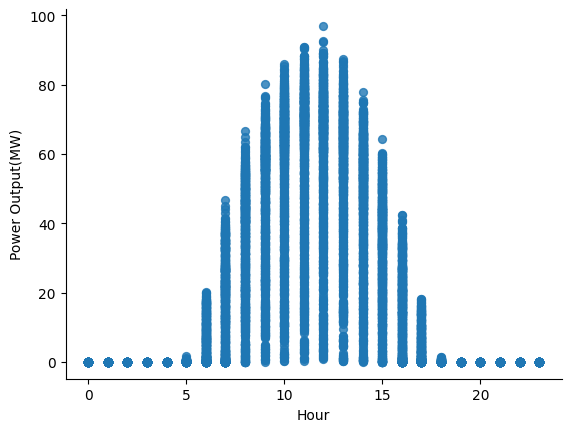

In [ ]:
# @title HOUR-MST vs Power Output(MW)

from matplotlib import pyplot as plt
df1.plot(kind='scatter', x='Hour', y='Power Output(MW)', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

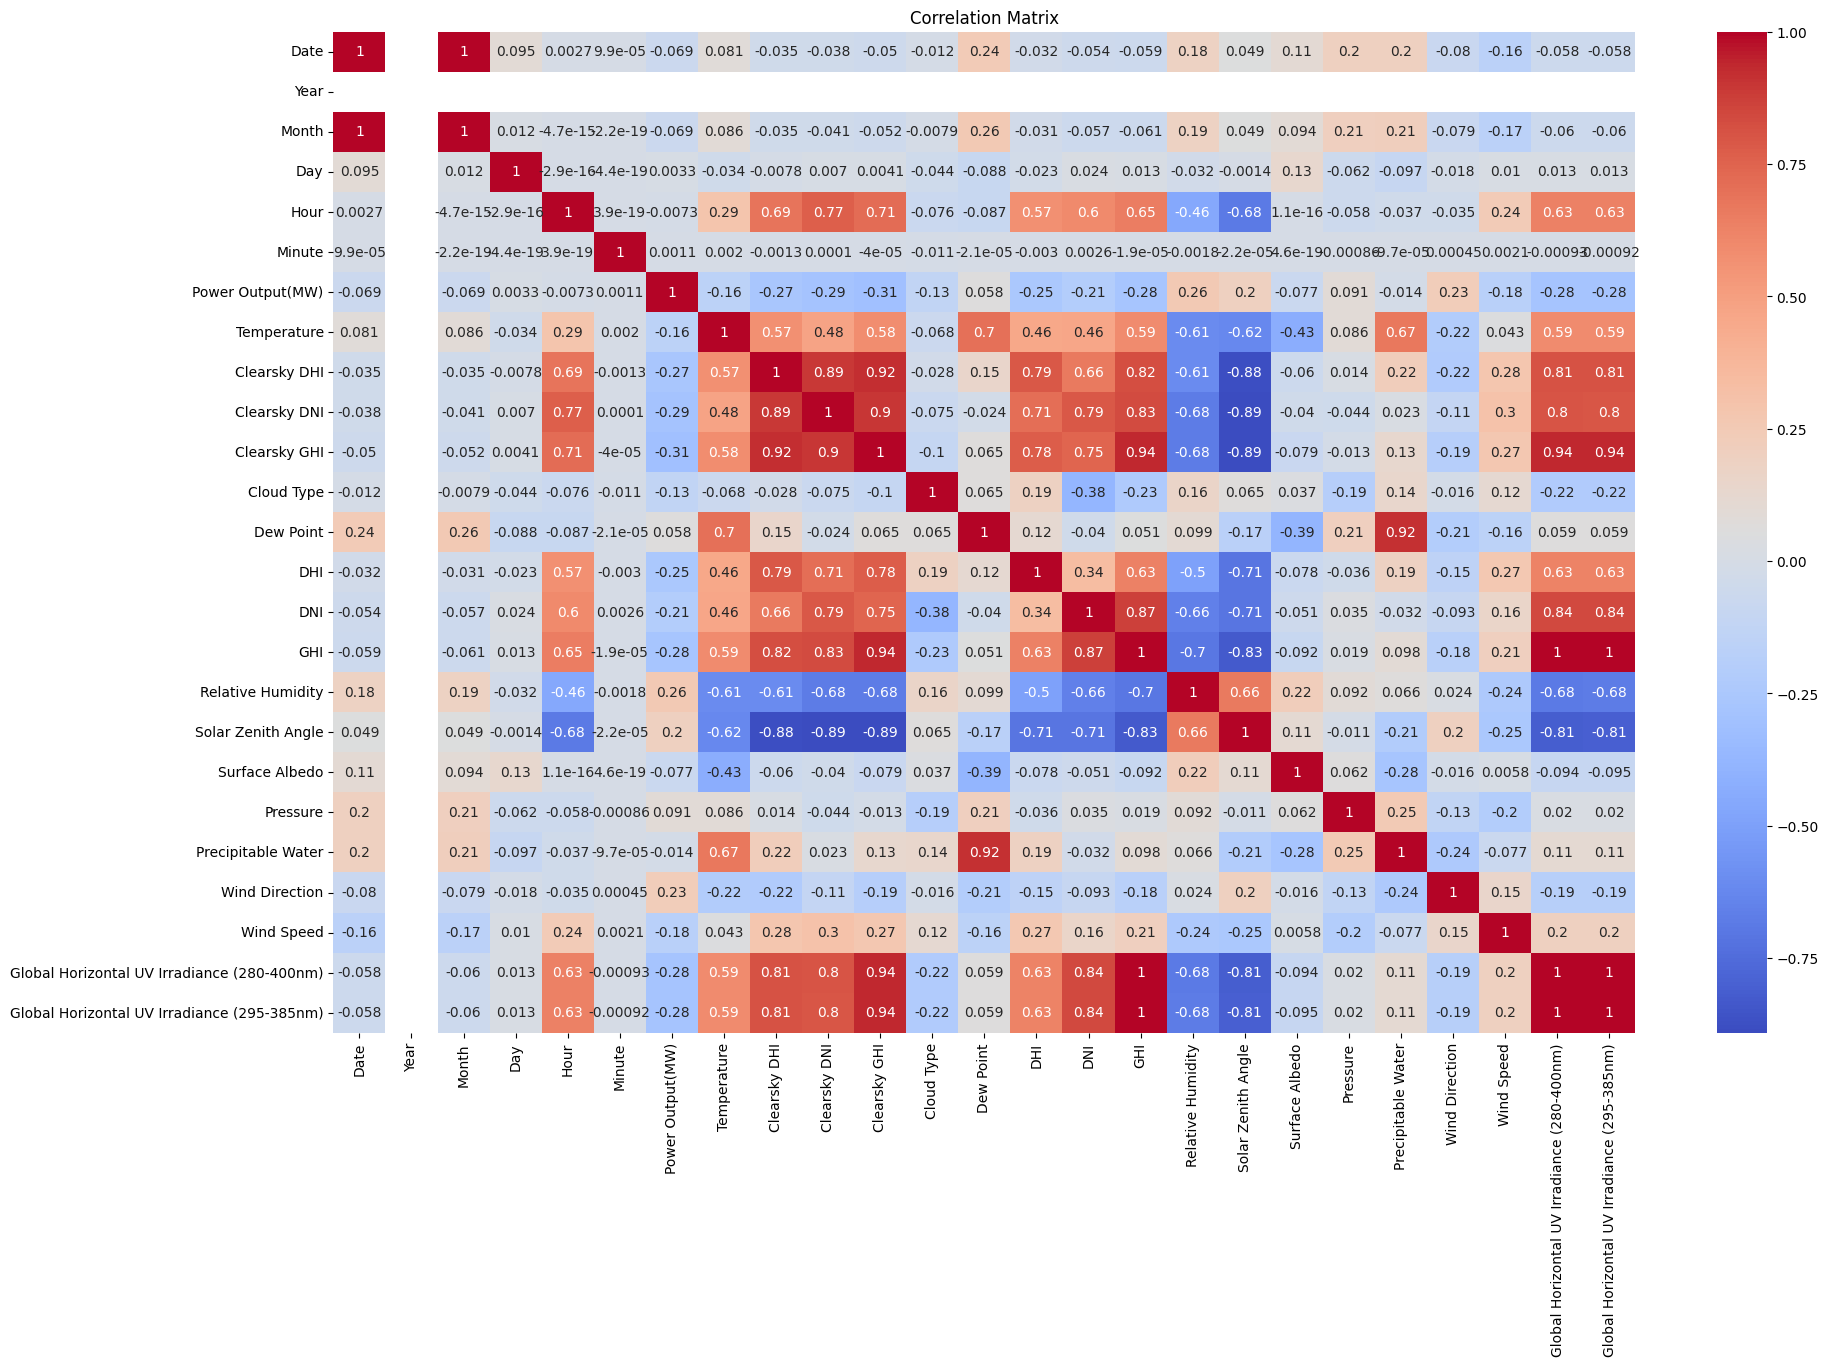

In [ ]:


import matplotlib.pyplot as plt
# Calculate the correlation matrix
corr_matrix = df1.corr()

# Create the heatmap
plt.figure(figsize=(21, 13))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()


From the heatmap, we can observe the correlation between different features and the "Power Output(MW)" variable.
Here are some potential observations:

Strong Positive Correlation:
Features with a high positive correlation value (close to 1) have a strong positive relationship with "Power Output(MW)".
This means that as these features increase, "Power Output(MW)" tends to increase as well.

Strong Negative Correlation:
Features with a high negative correlation value (close to -1) have a strong negative relationship with "Power Output(MW)".
This means that as these features increase, "Power Output(MW)" tends to decrease.

Weak Correlation:
Features with correlation values close to 0 have a weak or no relationship with "Power Output(MW)".

Dropping the featurers with low correlation with Power Output

In [ ]:
df1.drop(['Hour','Day','Month','Year','Minute','Dew Point','Surface Albedo','Pressure','Precipitable Water'],axis = 1,inplace = True)

In [ ]:
df1

,Date,Power Output(MW),Temperature,Clearsky DHI,Clearsky DNI,Clearsky GHI,Cloud Type,DHI,DNI,GHI,Relative Humidity,Solar Zenith Angle,Wind Direction,Wind Speed,Global Horizontal UV Irradiance (280-400nm),Global Horizontal UV Irradiance (295-385nm)
0,2006-01-01 00:00:00,0.0,7.1,0,0,0,0,0,0,0,53.04,93.61,358,1.4,0.0000,0.0000
1,2006-01-01 00:30:00,0.0,6.7,0,0,0,0,0,0,0,54.58,98.82,353,1.4,0.0000,0.0000
2,2006-01-01 01:00:00,0.0,6.4,0,0,0,4,0,0,0,55.85,104.20,349,1.4,0.0000,0.0000
3,2006-01-01 01:30:00,0.0,6.2,0,0,0,7,0,0,0,56.56,109.71,341,1.3,0.0000,0.0000
4,2006-01-01 02:00:00,0.0,6.0,0,0,0,4,0,0,0,57.83,115.33,333,1.3,0.0000,0.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17515,2006-12-31 21:30:00,0.0,-0.2,46,916,332,0,46,916,332,67.71,71.83,41,1.8,16.7143,12.9115
17516,2006-12-31 22:00:00,0.0,-0.9,41,863,258,0,41,863,258,70.61,75.42,52,1.2,12.5707,9.6533
17517,2006-12-31 22:30:00,0.0,-2.5,34,780,177,0,34,780,177,79.43,79.44,72,1.1,8.4365,6.4334
17518,2006-12-31 23:00:00,0.0,-4.0,25,642,95,0,25,642,95,70.31,83.80,92,0.9,0.0000,0.0000


In [ ]:
y = df1.corrwith(df1["Power Output(MW)"])

In [ ]:
y.drop('Date', inplace=True)

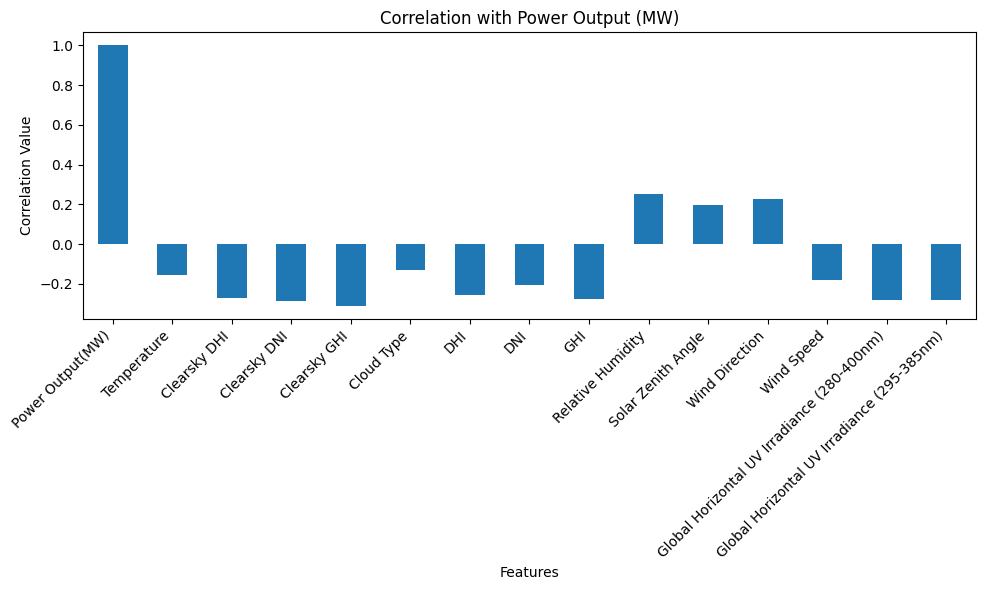

In [ ]:
# prompt: plot a bar plot for correlation values obtained in y

import matplotlib.pyplot as plt

# Assuming 'y' is already calculated as in your provided code
# y = df1.corrwith(df1["Power Output(MW)"])

plt.figure(figsize=(10, 6))
y.plot(kind='bar')
plt.title('Correlation with Power Output (MW)')
plt.xlabel('Features')
plt.ylabel('Correlation Value')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.tight_layout()  # Adjust layout to prevent labels from overlapping
plt.show()

<ipython-input-22-fb0dd2df6181>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_12['Month'] = df_12['Date'].dt.month_name()


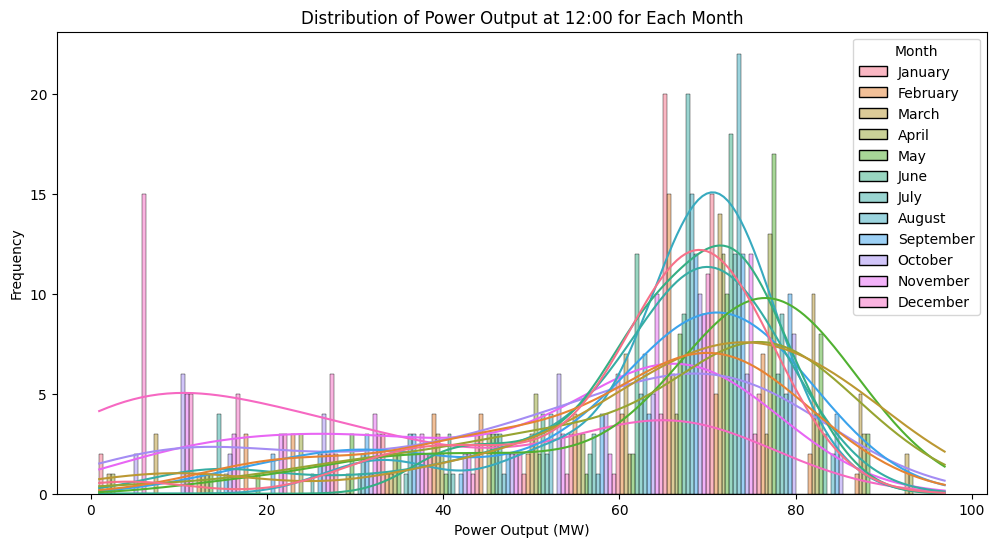

In [ ]:
# prompt: plot the distribution of all Power Output(MW) data at 12:00 for each month

# Assuming df1 is already loaded and processed as in the provided code.
import matplotlib.pyplot as plt
import seaborn as sns

# Filter data for 12:00
df1['Date'] = pd.to_datetime(df1['Date'])
df_12 = df1[df1['Date'].dt.hour == 12]
df_12['Month'] = df_12['Date'].dt.month_name()
# Create the plot
plt.figure(figsize=(12, 6))
sns.histplot(data=df_12, x='Power Output(MW)', hue='Month', multiple='dodge', kde=True)
plt.xlabel('Power Output (MW)')
plt.ylabel('Frequency')
plt.title('Distribution of Power Output at 12:00 for Each Month')
plt.show()

**Univariate LSTM Model**


Converting the Dataset into Supervised data with inputs and outputs. The input x is collected with 5 data points from start with next 6th point as the output label. Similarly this datapoints at a window of 5 is collected throughout the entire dataset.

In [ ]:
# [[[1], [2], [3], [4], [5]]] [6]
# [[[2], [3], [4], [5], [6]]] [7]
# [[[3], [4], [5], [6], [7]]] [8]

def df_to_X_y(df, window_size=5):
  df_as_np = df.to_numpy()
  X = []
  y = []
  for i in range(len(df_as_np)-window_size):
    row = [[a] for a in df_as_np[i:i+window_size]]
    X.append(row)
    label = df_as_np[i+window_size]
    y.append(label)
  return np.array(X), np.array(y)

In [ ]:
power = df1['Power Output(MW)']

In [ ]:
WINDOW_SIZE = 12
X1, y1 = df_to_X_y(power, WINDOW_SIZE)
X1.shape, y1.shape

((17508, 12, 1), (17508,))

In [ ]:
X_train1, y_train1 = X1[:15000], y1[:15000]
X_test1, y_test1 = X1[15000:], y1[15000:]
X_train1.shape, y_train1.shape, X_test1.shape, y_test1.shape

((15000, 12, 1), (15000,), (2508, 12, 1), (2508,))

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.metrics import RootMeanSquaredError
from tensorflow.keras.optimizers import Adam

model1 = Sequential()
model1.add(InputLayer((12, 1)))
model1.add(LSTM(64))
model1.add(Dense(8, 'relu'))
model1.add(Dense(1, 'linear'))

model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 64)                  │          16,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 8)                   │             520 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 17,425 (68.07 KB)

 Trainable params: 17,425 (68.07 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
cp1 = ModelCheckpoint('model1.keras', save_best_only=True)
model1.compile(loss=MeanSquaredError(), optimizer=Adam(learning_rate=0.0001), metrics=[RootMeanSquaredError()])

In [ ]:
model1.fit(X_train1, y_train1, epochs=50, callbacks=[cp1])

Epoch 1/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 978.3341 - root_mean_squared_error: 31.2658
Epoch 2/50


/usr/local/lib/python3.10/dist-packages/keras/src/callbacks/model_checkpoint.py:206: UserWarning: Can save best model only with val_loss available, skipping.
  self._save_model(epoch=epoch, batch=None, logs=logs)


469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 507.0921 - root_mean_squared_error: 22.4874
Epoch 3/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 280.2869 - root_mean_squared_error: 16.7273
Epoch 4/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 160.5794 - root_mean_squared_error: 12.6623
Epoch 5/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 91.6214 - root_mean_squared_error: 9.5616
Epoch 6/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 57.2042 - root_mean_squared_error: 7.5571
Epoch 7/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 40.4355 - root_mean_squared_error: 6.3548
Epoch 8/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 32.8317 - root_mean_squared_error: 5.7292
Epoch 9/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 29.2310 - root_mean_squared_error: 5.4056
Epoch 10/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 27.8271 - root_mean_squared_error: 5.2734
Epoch 11/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 26.0348 - root_mean_squ

In [ ]:
train_predictions = model1.predict(X_train1).flatten()
train_results = pd.DataFrame(data={'Train Predictions':train_predictions, 'Actuals':y_train1})
train_results

469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step


,Train Predictions,Actuals
0,0.200011,0.000000
1,0.200011,0.000000
2,0.200011,0.000000
3,0.200011,2.116667
4,13.616665,19.033333
...,...,...
14995,23.974348,13.700000
14996,13.267217,0.783333
14997,2.485475,0.000000
14998,1.364403,0.000000


Trainig Predicitions vs actuals

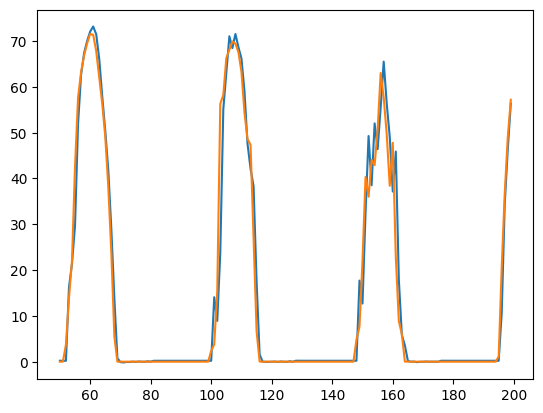

In [ ]:
import matplotlib.pyplot as plt
plt.plot(train_results['Train Predictions'][50:200])
plt.plot(train_results['Actuals'][50:200])

In [ ]:
test_predictions = model1.predict(X_test1).flatten()
test_results = pd.DataFrame(data={'Test Predictions':test_predictions, 'Actuals':y_test1})
test_results

79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


,Test Predictions,Actuals
0,-0.161577,0.0
1,-0.115952,0.0
2,0.035792,0.0
3,0.047670,0.0
4,0.064608,0.0
...,...,...
2503,0.038837,0.0
2504,0.205692,0.0
2505,0.200011,0.0
2506,0.200011,0.0


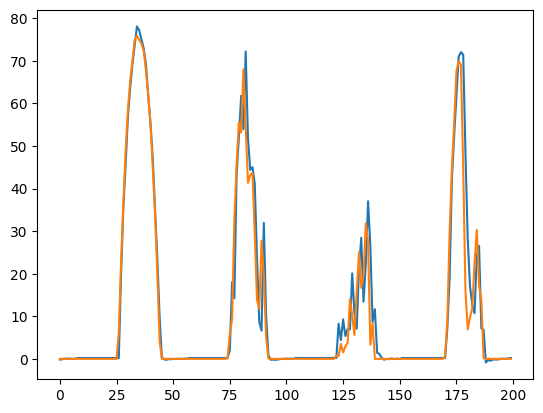

In [ ]:
plt.plot(test_results['Test Predictions'][:200])
plt.plot(test_results['Actuals'][:200])

In [ ]:
from sklearn.metrics import mean_squared_error
rmse = np.sqrt(mean_squared_error(y_test1, test_predictions))
mae = np.mean(np.abs(y_test1 - test_predictions))
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")

Root Mean Squared Error (RMSE): 5.4922
Mean Absolute Error (MAE): 2.4269


In [ ]:
forecast_steps = 48  # Forecast for 24 hours
forecast = []

# Start with the last sequence in the test set
input_seq = X_test1[-1].reshape(1, X_test1.shape[1], X_test1.shape[2])

for _ in range(forecast_steps):
    pred = model1.predict(input_seq)  # Predict the next value
    forecast.append(pred[0, 0])  # Append the predicted value

    # Update the input sequence: remove the first step and append the prediction
    new_step = np.concatenate([input_seq[:, 1:, :], pred.reshape(1, 1, -1)], axis=1)
    input_seq = new_step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━

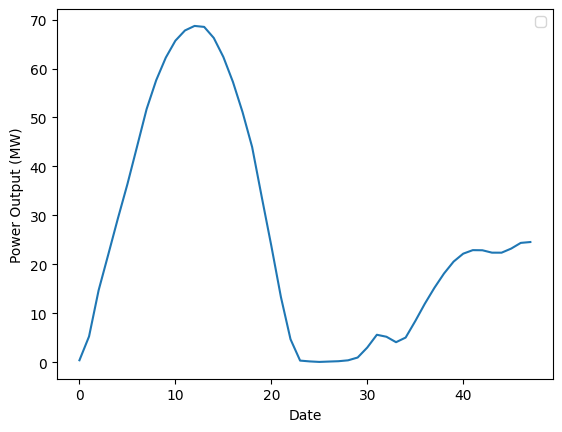

In [ ]:
plt.plot(forecast)
plt.xlabel('Date')
plt.ylabel('Power Output (MW)')
plt.legend()
plt.show()

**Multivariate LSTM Model**

In [ ]:
test_split=round(len(df1)*0.20)
df_for_training=df1[:-test_split]
df_for_training = df_for_training.drop('Date', axis=1)
df_for_testing=df1[-test_split:]
df_for_testing = df_for_testing.drop('Date', axis=1)
print(df_for_training.shape)
print(df_for_testing.shape)

(14016, 15)
(3504, 15)


In [ ]:
from sklearn import preprocessing

In [ ]:
scaler = preprocessing.StandardScaler()
df_train = scaler.fit_transform(df_for_training)
df_test= scaler.transform(df_for_testing)

In [ ]:
df_train.shape

(14016, 15)

In [ ]:
def createXY(dataset,n_past):
    dataX = []
    dataY = []
    for i in range(n_past, len(dataset)):
            dataX.append(dataset[i - n_past:i, 0:dataset.shape[1]])
            dataY.append(dataset[i,0])
    return np.array(dataX),np.array(dataY)
trainX,trainY=createXY(df_train,12)
testX,testY=createXY(df_test,12)

In [ ]:
print("trainX Shape-- ",trainX.shape)
print("trainY Shape-- ",trainY.shape)

trainX Shape--  (14004, 12, 15)
trainY Shape--  (14004,)


In [ ]:
print("testX Shape-- ",testX.shape)
print("testY Shape-- ",testY.shape)

testX Shape--  (3492, 12, 15)
testY Shape--  (3492,)


In [ ]:
import numpy as np
import pandas as pd
import tensorflow
from matplotlib import pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense, Dropout,InputLayer
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.metrics import RootMeanSquaredError
from tensorflow.keras.optimizers import Adam


In [ ]:
model3 = Sequential()
model3.add(InputLayer((12, 15)))
model3.add(LSTM(64))
model3.add(Dense(8, 'relu'))
model3.add(Dense(1, 'linear'))
model3.compile(loss=MeanSquaredError(), optimizer=Adam(learning_rate=0.0001), metrics=[RootMeanSquaredError()])

model3.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                        │ (None, 64)                  │          20,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 8)                   │             520 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 21,009 (82.07 KB)

 Trainable params: 21,009 (82.07 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model3.fit(trainX, trainY, epochs=50, batch_size=32)

Epoch 1/50
438/438 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 0.5234 - root_mean_squared_error: 0.7142
Epoch 2/50
438/438 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.1095 - root_mean_squared_error: 0.3307
Epoch 3/50
438/438 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0775 - root_mean_squared_error: 0.2783
Epoch 4/50
438/438 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 0.0626 - root_mean_squared_error: 0.2501
Epoch 5/50
438/438 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 0.0519 - root_mean_squared_error: 0.2278
Epoch 6/50
438/438 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 0.0476 - root_mean_squared_error: 0.2181
Epoch 7/50
438/438 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0427 - root_mean_squared_error: 0.2066
Epoch 8/50
438/438 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.0407 - root_mean_squared_error: 0.2016
Epoch 9/50
438/438 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0422 - root_mean_squared_error: 0.2054
Epoch 10/50
438/438 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0408 - root_mean_squared_

In [ ]:
prediction2=model3.predict(testX)
print("prediction\n", prediction2)
print("\nPrediction Shape-",prediction2.shape)

110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
prediction
 [[-0.5887104 ]
 [-0.5491399 ]
 [-0.5010815 ]
 ...
 [-0.71498114]
 [-0.7193938 ]
 [-0.7233411 ]]

Prediction Shape- (3492, 1)


In [ ]:
prediction_copies_array2 = np.repeat(prediction2,15, axis=-1)
pred2=scaler.inverse_transform(np.reshape(prediction_copies_array2,(len(prediction2),15)))[:,0]

In [ ]:
original_copies_array2 = np.repeat(testY,15, axis=-1)
original2=scaler.inverse_transform(np.reshape(original_copies_array2,(len(testY),15)))[:,0]

In [ ]:
from sklearn.metrics import mean_squared_error
rmse3 = np.sqrt(mean_squared_error(original2, pred2))
mae2 = np.mean(np.abs(original2 - pred2))
print(f"Root Mean Squared Error (RMSE): {rmse3:.4f}")
print(f"Mean Absolute Error(MAE): {mae2:.4f}")

Root Mean Squared Error (RMSE): 5.4223
Mean Absolute Error(MAE): 2.9670


In [ ]:
prediction3 =model3.predict(trainX)
print("prediction\n", prediction3)
print("\nPrediction Shape-",prediction3.shape)

438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
prediction
 [[-0.7265414 ]
 [-0.70728004]
 [-0.6804494 ]
 ...
 [-0.7015475 ]
 [-0.7007283 ]
 [-0.704995  ]]

Prediction Shape- (14004, 1)


In [ ]:
prediction_copies_array3 = np.repeat(prediction3,15, axis=-1)
pred3=scaler.inverse_transform(np.reshape(prediction_copies_array3,(len(prediction3),15)))[:,0]

In [ ]:
original_copies_array3 = np.repeat(trainY,15, axis=-1)
original3=scaler.inverse_transform(np.reshape(original_copies_array3,(len(trainY),15)))[:,0]

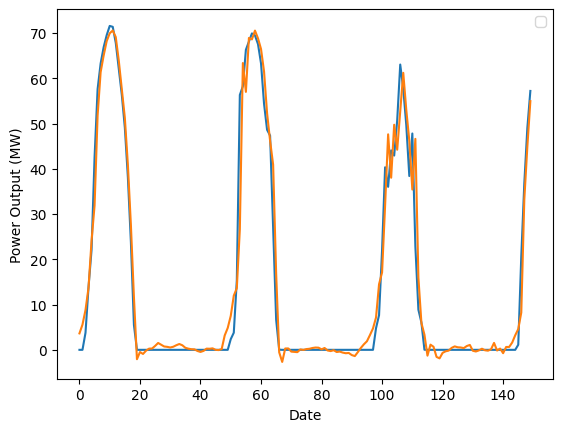

In [ ]:
plt.plot(original3[50:200])
plt.plot(pred3[50:200])
plt.xlabel('Date')
plt.ylabel('Power Output (MW)')
plt.legend()
plt.show()

In [ ]:
testX.shape

(3492, 12, 15)

In [ ]:
forecast_steps = 48  # Forecast for 24 hours
forecast = []

# Start with the last sequence in the test set
input_seq = testX[-1].reshape(1, testX.shape[1], testX.shape[2])

for _ in range(forecast_steps):
    pred = model3.predict(input_seq)  # Predict the next value
    forecast.append(pred[0, 0])  # Append the predicted value
    pred_arr = np.repeat(pred,15, axis=-1)

    # Update the input sequence: remove the first step and append the prediction
    new_step = np.concatenate([input_seq[:, 1:, :], pred_arr.reshape(1, 1, -1)], axis=1)
    input_seq = new_step

# Inverse scale the forecasted values
#forecast_inverse = scaler.inverse_transform(np.reshape(forecast,(forecast_steps)))[:,0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━

In [ ]:
len(forecast)

48

In [ ]:
forecast_array = np.array(forecast).reshape(-1, 1)
forecast_array_padded = np.zeros((forecast_array.shape[0], 15))  # Create an array with 15 columns
forecast_array_padded[:, 0] = forecast_array[:, 0]  # Fill the first column with the forecast values

forecast_inverse = scaler.inverse_transform(forecast_array_padded)[:, 0]

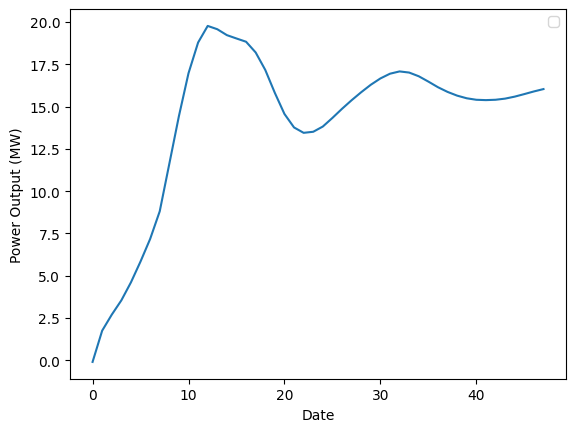

In [ ]:
plt.plot(forecast_inverse)
plt.xlabel('Date')
plt.ylabel('Power Output (MW)')
plt.legend()
plt.show()

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader

class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Create dataset and dataloader
X = np.concatenate((trainX, testX))
y = np.concatenate((trainY, testY))
dataset = TimeSeriesDataset(X, y)
train_size = int(0.8 * len(dataset))
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, len(dataset) - train_size])


train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [ ]:
# Sequence Data Preparation
from torch.utils.data import DataLoader, TensorDataset

SEQUENCE_SIZE = 12


def createXY(dataset,n_past):
    dataX = []
    dataY = []
    for i in range(n_past, len(dataset)):
            dataX.append(dataset[i - n_past:i, 0:dataset.shape[1]])
            dataY.append(dataset[i,0])
    return torch.tensor(dataX, dtype=torch.float32).view(-1, 12, 15), torch.tensor(dataY, dtype=torch.float32).view(-1, 1)

trainX,trainY=createXY(df_train,12)
testX,testY=createXY(df_test,12)



# Setup data loaders for batch
train_dataset = TensorDataset(trainX, trainY)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

test_dataset = TensorDataset(testX, testY)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

<ipython-input-26-c4da363317cd>:13: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:278.)
  return torch.tensor(dataX, dtype=torch.float32).view(-1, 12, 15), torch.tensor(dataY, dtype=torch.float32).view(-1, 1)


In [ ]:
# Positional Encoding for Transformer
import torch
import torch.nn as nn
from torch.nn import TransformerEncoder, TransformerEncoderLayer
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0).transpose(0, 1)
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:x.size(0), :]
        return self.dropout(x)

In [ ]:
# Model definition using Transformer
class TransformerModel(nn.Module):
    def __init__(self, input_dim=15, d_model=64, nhead=4, num_layers=2, dropout=0.2):
        super(TransformerModel, self).__init__()

        self.encoder = nn.Linear(input_dim, d_model)
        self.pos_encoder = PositionalEncoding(d_model, dropout)
        encoder_layers = nn.TransformerEncoderLayer(d_model, nhead)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layers, num_layers)
        self.decoder = nn.Linear(d_model, 1)

    def forward(self, x):
        x = self.encoder(x)
        x = self.pos_encoder(x)
        x = self.transformer_encoder(x)
        x = self.decoder(x[:, -1, :])
        return x
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = TransformerModel().to(device)

/usr/local/lib/python3.10/dist-packages/torch/nn/modules/transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


In [ ]:
from torch.optim.lr_scheduler import ReduceLROnPlateau # Import ReduceLROnPlateau
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = ReduceLROnPlateau(optimizer, 'min', factor=0.5, patience=3, verbose=True)

epochs = 1000
early_stop_count = 0
min_val_loss = float('inf')

for epoch in range(epochs):
    model.train()
    for batch in train_loader:
        x_batch, y_batch = batch
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(x_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

    # Validation
    model.eval()
    val_losses = []
    with torch.no_grad():
        for batch in test_loader:
            x_batch, y_batch = batch
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            outputs = model(x_batch)
            loss = criterion(outputs, y_batch)
            val_losses.append(loss.item())

    val_loss = np.mean(val_losses)
    scheduler.step(val_loss)


    if val_loss < min_val_loss:
        min_val_loss = val_loss
        early_stop_count = 0
    else:
        early_stop_count += 1

    if early_stop_count >= 5:
        print("Early stopping!")
        break
    print(f"Epoch {epoch + 1}/{epochs}, Validation Loss: {val_loss:.4f}")

/usr/local/lib/python3.10/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1/1000, Validation Loss: 0.0574
Epoch 2/1000, Validation Loss: 0.0691
Epoch 3/1000, Validation Loss: 0.0579
Epoch 4/1000, Validation Loss: 0.0631
Epoch 5/1000, Validation Loss: 0.0452
Epoch 6/1000, Validation Loss: 0.0501
Epoch 7/1000, Validation Loss: 0.0655
Epoch 8/1000, Validation Loss: 0.0477
Epoch 9/1000, Validation Loss: 0.0470
Early stopping!


In [ ]:
model.eval()
predictions = []
with torch.no_grad():
    for batch in test_loader:
        x_batch, y_batch = batch
        x_batch = x_batch.to(device)
        outputs = model(x_batch)
        predictions.extend(outputs.squeeze().tolist())




In [ ]:
predictions_array = np.array(predictions)
predictions_copy = np.repeat(predictions_array,15, axis=-1)
predictions_copy.shape
pred1 =scaler.inverse_transform(np.reshape(predictions_copy,(len(predictions),15)))[:,0]




In [ ]:
original_copies_array = np.repeat(testY,15, axis=-1)
original=scaler.inverse_transform(np.reshape(original_copies_array,(len(testY),15)))[:,0]

In [ ]:
rmse = np.sqrt(np.mean((pred1 - original)**2))
mae = np.mean(np.abs(pred1 - original))

In [ ]:
print(f"Score (RMSE): {rmse:.4f}")

Score (RMSE): 6.0330


In [ ]:
print(f"Score (MAE): {mae:.4f}")

Score (MAE): 3.6093


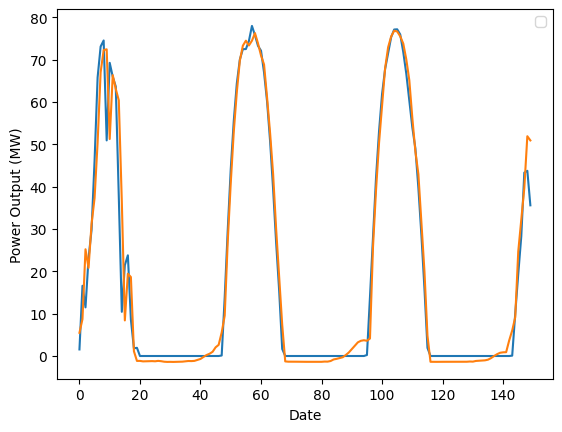

In [ ]:
plt.plot(original[50:200])
plt.plot(pred1[50:200])
plt.xlabel('Date')
plt.ylabel('Power Output (MW)')
plt.legend()
plt.show()

In [ ]:
# Model definition using Transformer
class TransformerModel(nn.Module):
    def __init__(self, input_dim=15, d_model=64, nhead=4, num_layers=6, dropout=0.2):
        super(TransformerModel, self).__init__()

        self.encoder = nn.Linear(input_dim, d_model)
        self.pos_encoder = PositionalEncoding(d_model, dropout)
        encoder_layers = nn.TransformerEncoderLayer(d_model, nhead)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layers, num_layers)
        self.decoder = nn.Linear(d_model, 1)

    def forward(self, x):
        x = self.encoder(x)
        x = self.pos_encoder(x)
        x = self.transformer_encoder(x)
        x = self.decoder(x[:, -1, :])
        return x
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = TransformerModel().to(device)

/usr/local/lib/python3.10/dist-packages/torch/nn/modules/transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


In [ ]:
from torch.optim.lr_scheduler import ReduceLROnPlateau # Import ReduceLROnPlateau
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = ReduceLROnPlateau(optimizer, 'min', factor=0.5, patience=3, verbose=True)

epochs = 1000
early_stop_count = 0
min_val_loss = float('inf')

for epoch in range(epochs):
    model.train()
    for batch in train_loader:
        x_batch, y_batch = batch
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(x_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

    # Validation
    model.eval()
    val_losses = []
    with torch.no_grad():
        for batch in test_loader:
            x_batch, y_batch = batch
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            outputs = model(x_batch)
            loss = criterion(outputs, y_batch)
            val_losses.append(loss.item())

    val_loss = np.mean(val_losses)
    scheduler.step(val_loss)


    if val_loss < min_val_loss:
        min_val_loss = val_loss
        early_stop_count = 0
    else:
        early_stop_count += 1

    if early_stop_count >= 5:
        print("Early stopping!")
        break
    print(f"Epoch {epoch + 1}/{epochs}, Validation Loss: {val_loss:.4f}")

/usr/local/lib/python3.10/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1/1000, Validation Loss: 0.7030
Epoch 2/1000, Validation Loss: 0.7620
Epoch 3/1000, Validation Loss: 0.1652
Epoch 4/1000, Validation Loss: 0.1326
Epoch 5/1000, Validation Loss: 0.0709
Epoch 6/1000, Validation Loss: 0.0673
Epoch 8/1000, Validation Loss: 0.0588
Epoch 9/1000, Validation Loss: 0.0488
Epoch 10/1000, Validation Loss: 0.0453
Epoch 11/1000, Validation Loss: 0.0829
Epoch 12/1000, Validation Loss: 0.0565
Epoch 13/1000, Validation Loss: 0.0600
Epoch 14/1000, Validation Loss: 0.0559
Early stopping!


In [ ]:
model.eval()
predictions = []
with torch.no_grad():
    for batch in test_loader:
        x_batch, y_batch = batch
        x_batch = x_batch.to(device)
        outputs = model(x_batch)
        predictions.extend(outputs.squeeze().tolist())

In [ ]:
predictions_array = np.array(predictions)
predictions_copy = np.repeat(predictions_array,15, axis=-1)
predictions_copy.shape
pred1 =scaler.inverse_transform(np.reshape(predictions_copy,(len(predictions),15)))[:,0]

In [ ]:
original_copies_array = np.repeat(testY,15, axis=-1)
original=scaler.inverse_transform(np.reshape(original_copies_array,(len(testY),15)))[:,0]

In [ ]:
rmse = np.sqrt(np.mean((pred1 - original)**2))
mae = np.mean(np.abs(pred1 - original))
print(f"Score (RMSE): {rmse:.4f}")
print(f"Score (MAE): {mae:.4f}")

Score (RMSE): 5.9678
Score (MAE): 2.8899


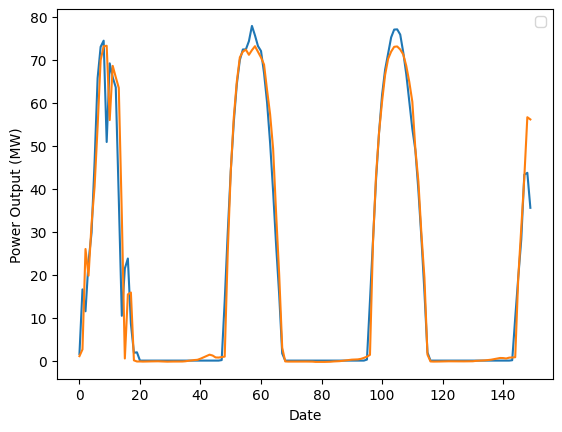

In [ ]:
# Plot actual vs predictions
plt.plot(original[50:200])
plt.plot(pred1[50:200])
plt.xlabel('Date')
plt.ylabel('Power Output (MW)')
plt.legend()
plt.show()